In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df= pd.read_excel("C:\Python for data analytics\Machine Learning\Group assignment\Houses for rent in Madrid.xlsx")
df.head()


<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\vldma\AppData\Local\Temp\ipykernel_24540\892083538.py:7: SyntaxWarning: invalid escape sequence '\P'
  df= pd.read_excel("C:\Python for data analytics\Machine Learning\Group assignment\Houses for rent in Madrid.xlsx")


,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


In [82]:
len(df)

2089

In [83]:
df.columns=df.columns.str.lower().str.strip().str.replace(' ', '_')

Feature engineering part

In [84]:
Total=df.isna().sum()
Percent=Total/df.shape[0]*100
missing_data=pd.DataFrame({'Total':Total,'Percent':Percent})
missing_data.sort_values(by='Percent',ascending=False)

,Total,Percent
number,1342,64.241264
outer,162,7.754907
floor,141,6.749641
elevator,133,6.366683
bedrooms,89,4.260412
area,4,0.191479
address,0,0.000000
rent,0,0.000000
id,0,0.000000
district,0,0.000000


In [85]:
df.drop(columns=['number','id'], inplace=True)

The variables presenting missing values are Number, Bedrooms, Floor, Outer, and Elevator. The last 4 have 4.2%, 6.7%, 7.75%, and 6.36% respectively missing values. Since Number has an overwhelming 64.2% missing value, I advocate for dropping it. We will try to solve the Floor and Outer wherever possible.

In [86]:
df['area']=df['area'].str.lower().str.strip()

In [87]:
import re
p= "en"
df["area"]=df["area"].str.replace(f'^{p}\s+', '', regex=True)
df["area"]

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\vldma\AppData\Local\Temp\ipykernel_24540\723287161.py:3: SyntaxWarning: invalid escape sequence '\s'
  df["area"]=df["area"].str.replace(f'^{p}\s+', '', regex=True)


0          quintana
1       costillares
2            colina
3       san pascual
4            ventas
           ...     
2084    los rosales
2085    los ángeles
2086     san andrés
2087     san andrés
2088     san andrés
Name: area, Length: 2089, dtype: object

In [88]:
import re
from sklearn.preprocessing import OneHotEncoder

area_cat_1hot=pd.get_dummies(df['area'])
df=pd.concat([df,area_cat_1hot],axis=1)
df.head()


,district,address,area,rent,bedrooms,sq.mt,floor,outer,elevator,penthouse,...,valdemarín,valdezarza,vallehermoso,ventas,ventilla-almenara,vinateros,virgen del cortijo - manoteras,vista alegre,zofá­o,águilas
0,Ciudad Lineal,Piso en Quintana,quintana,1300,2.0,72,3.0,1.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
1,Ciudad Lineal,Piso en calle de Arturo Soria,costillares,3000,5.0,260,2.0,1.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
2,Ciudad Lineal,Piso en calle de Vicente Muzas,colina,1300,2.0,100,3.0,1.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
3,Ciudad Lineal,Piso en calle Badajoz,san pascual,1600,3.0,120,4.0,1.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
4,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,ventas,800,2.0,60,3.0,1.0,0.0,0,...,False,False,False,True,False,False,False,False,False,False


In [89]:
df.drop(columns=['area','recoletos'], inplace=True)

In [90]:
df.drop(columns=['district'], inplace=True)


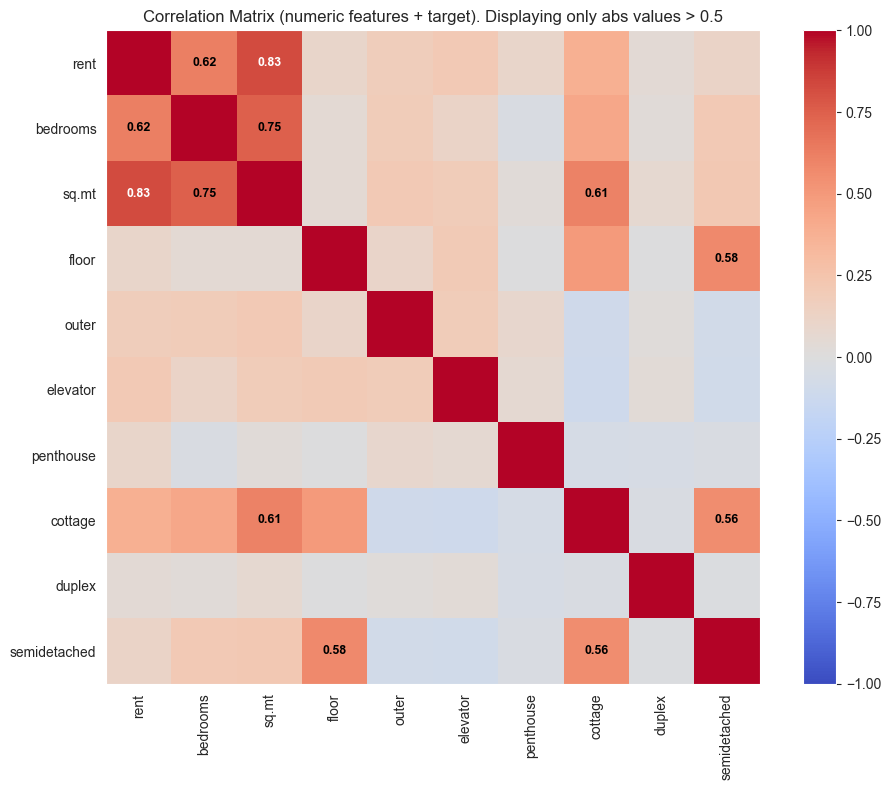

In [91]:
num_pred = [c for c in df.select_dtypes(include=[np.number]).columns]
corr = df[num_pred].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.5 and i != j:
            ax.text(j, i, f'{valor:.2f}',
                    ha='center', va='center',
                    color='white' if abs(valor) > 0.8 else 'black',
                    fontsize=9, fontweight='bold')

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
plt.colorbar(cax)
ax.set_title('Correlation Matrix (numeric features + target). Displaying only abs values > 0.5')
plt.tight_layout()
plt.show()

In [92]:
df.drop(columns=["sq.mt"], inplace= True)


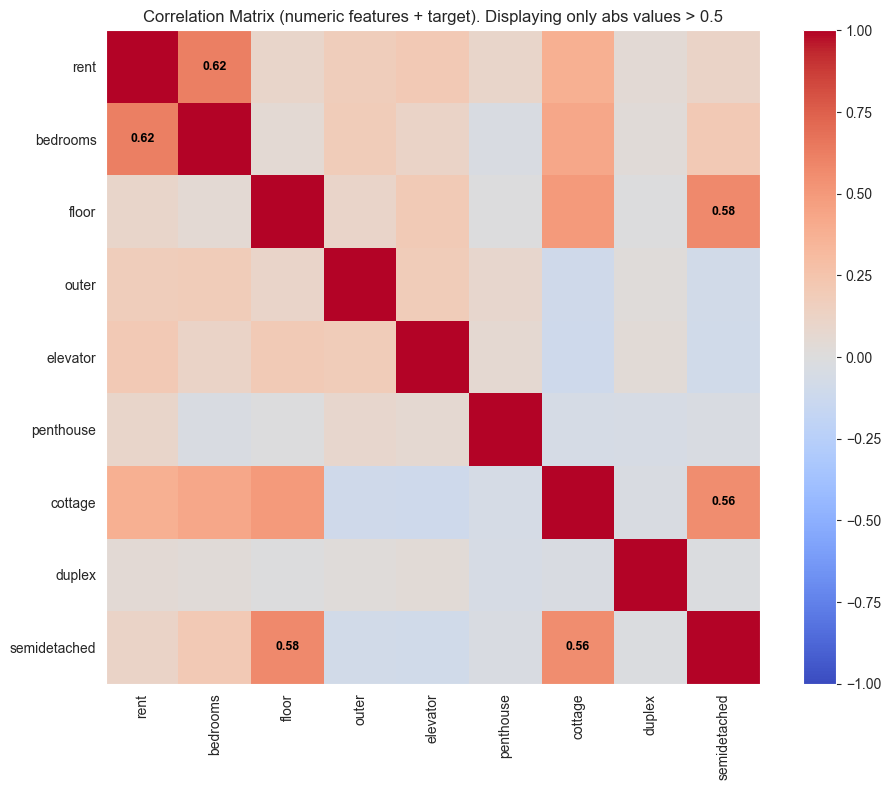

In [93]:
num_pred = [c for c in df.select_dtypes(include=[np.number]).columns]
corr = df[num_pred].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.5 and i != j:
            ax.text(j, i, f'{valor:.2f}',
                    ha='center', va='center',
                    color='white' if abs(valor) > 0.8 else 'black',
                    fontsize=9, fontweight='bold')

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
plt.colorbar(cax)
ax.set_title('Correlation Matrix (numeric features + target). Displaying only abs values > 0.5')
plt.tight_layout()
plt.show()

In [94]:
df.drop(columns=["address"],inplace=True)


In [95]:
df.head()

,rent,bedrooms,floor,outer,elevator,penthouse,cottage,duplex,semidetached,12 de octubre-orcasur,...,valdemarín,valdezarza,vallehermoso,ventas,ventilla-almenara,vinateros,virgen del cortijo - manoteras,vista alegre,zofá­o,águilas
0,1300,2.0,3.0,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
1,3000,5.0,2.0,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
2,1300,2.0,3.0,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
3,1600,3.0,4.0,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
4,800,2.0,3.0,1.0,0.0,0,0,0,0,False,...,False,False,False,True,False,False,False,False,False,False


In [96]:
df=df.dropna()

In [97]:
# IQR for multiple columns
cols=[column for column in df.columns]
def remove_outliers_multiple(df,columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    return df

coloane=df.columns
df2 = remove_outliers_multiple(df, ["rent","floor","bedrooms"])

In [98]:

names= df2.iloc[:,0].to_list()
print(names)
len(names)
X=df2.iloc[:,4:]
X.head()

[1300, 3000, 1300, 1600, 800, 1850, 850, 850, 1900, 1300, 3200, 1700, 990, 1070, 870, 870, 830, 2500, 2200, 1300, 800, 1650, 2500, 1100, 790, 1450, 850, 2000, 2800, 3200, 1250, 1100, 1200, 850, 950, 800, 3000, 1900, 915, 1000, 2200, 1500, 1750, 3000, 1900, 3200, 3200, 3000, 680, 750, 1200, 875, 2500, 2950, 3100, 950, 750, 950, 1900, 1600, 800, 700, 1275, 825, 900, 850, 1900, 2000, 1300, 1000, 790, 1300, 1200, 950, 1650, 1150, 900, 950, 1800, 3500, 1300, 3200, 800, 1200, 1800, 2100, 1250, 1900, 3000, 895, 2200, 800, 1800, 899, 2250, 1000, 1500, 1300, 1900, 1400, 1250, 1900, 1500, 1300, 1200, 1500, 1350, 1350, 2300, 990, 990, 1845, 1100, 1700, 950, 1100, 1200, 1700, 1700, 1230, 1450, 1300, 1100, 880, 895, 726, 2450, 1100, 1350, 1300, 1500, 1350, 1500, 1550, 1350, 2300, 750, 1250, 4500, 1500, 2590, 1500, 900, 990, 1900, 900, 1100, 2300, 1200, 850, 1200, 900, 2000, 1200, 2200, 945, 1100, 1150, 1250, 700, 1750, 2300, 1100, 650, 800, 1100, 1100, 1200, 1300, 880, 1190, 1900, 1300, 1600, 970, 

,elevator,penthouse,cottage,duplex,semidetached,12 de octubre-orcasur,abrantes,acacias,adelfas,almagro,...,valdemarín,valdezarza,vallehermoso,ventas,ventilla-almenara,vinateros,virgen del cortijo - manoteras,vista alegre,zofá­o,águilas
0,1.0,0,0,0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.0,0,0,0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1.0,0,0,0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.0,0,0,0,0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.0,0,0,0,0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [99]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
numeric = df.select_dtypes(include=['number']).columns
print(numeric)

scaler = MinMaxScaler() # we will use 0-1 normalization
scaler.set_output(transform="pandas")
X_scaled = scaler.fit_transform(df[numeric])

X_df = df.copy()
X_df.update(X_scaled) # this replaces the numeric variables by their normalized version
X_df.head() # X_df is the new dataframe re-scaled

Index(['rent', 'bedrooms', 'floor', 'outer', 'elevator', 'penthouse',
       'cottage', 'duplex', 'semidetached'],
      dtype='object')


C:\Users\vldma\AppData\Local\Temp\ipykernel_24540\4232314067.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.05466238 0.16398714 0.05466238 ... 0.04180064 0.0192926  0.02893891]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_df.update(X_scaled) # this replaces the numeric variables by their normalized version


,rent,bedrooms,floor,outer,elevator,penthouse,cottage,duplex,semidetached,12 de octubre-orcasur,...,valdemarín,valdezarza,vallehermoso,ventas,ventilla-almenara,vinateros,virgen del cortijo - manoteras,vista alegre,zofá­o,águilas
0,0.054662,0.250,0.133333,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
1,0.163987,0.625,0.100000,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
2,0.054662,0.250,0.133333,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
3,0.073955,0.375,0.166667,1.0,1.0,0,0,0,0,False,...,False,False,False,False,False,False,False,False,False,False
4,0.022508,0.250,0.133333,1.0,0.0,0,0,0,0,False,...,False,False,False,True,False,False,False,False,False,False


In [100]:
from sklearn.metrics import pairwise_distances



distance_matrix_squared = pairwise_distances(X_df, metric='euclidean', squared=True) #squared euclidean distances
distance_df = pd.DataFrame(distance_matrix_squared, index=names, columns=names)

plt.figure(figsize=(12, 10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.heatmap(distance_df, cmap="coolwarm", annot=False, cbar=True)
plt.title("Distance heatmap", fontsize=16)

distance_df.to_excel("Distances.xlsx")

ValueError: Shape of passed values is (1819, 1819), indices imply (1676, 1676)

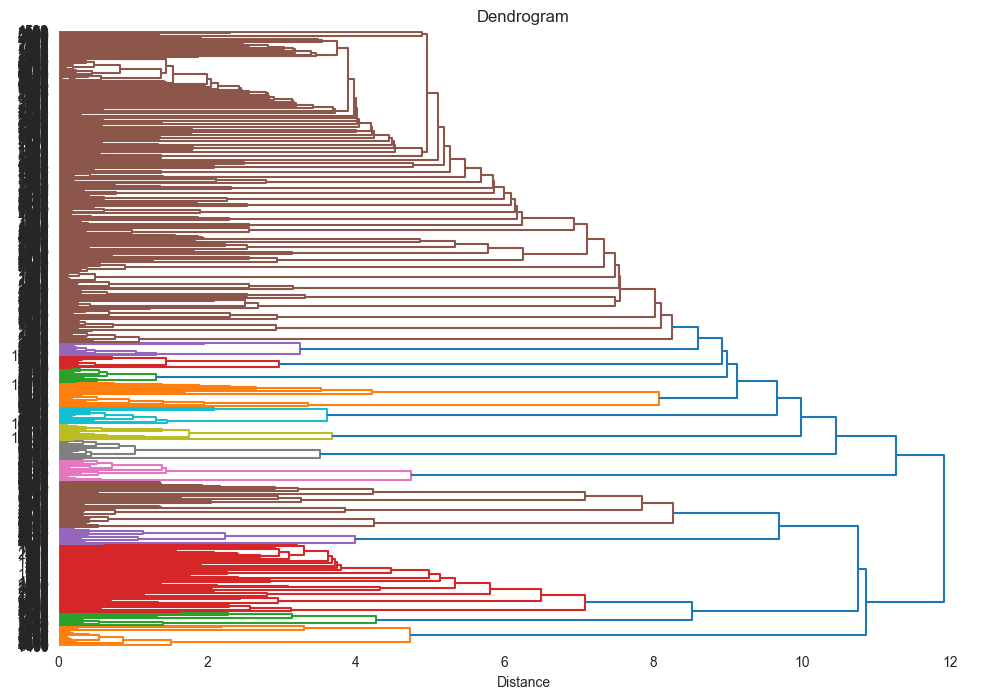

In [77]:
def plot_dendrogram(model, **kwargs):
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

linkage_matrix = linkage(X_df, method='ward') # other linkage methods: complete, average, single
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix, labels=names, leaf_rotation=0, leaf_font_size=10, orientation='right')
plt.title("Dendrogram")
plt.xlabel("Distance")
plt.show()

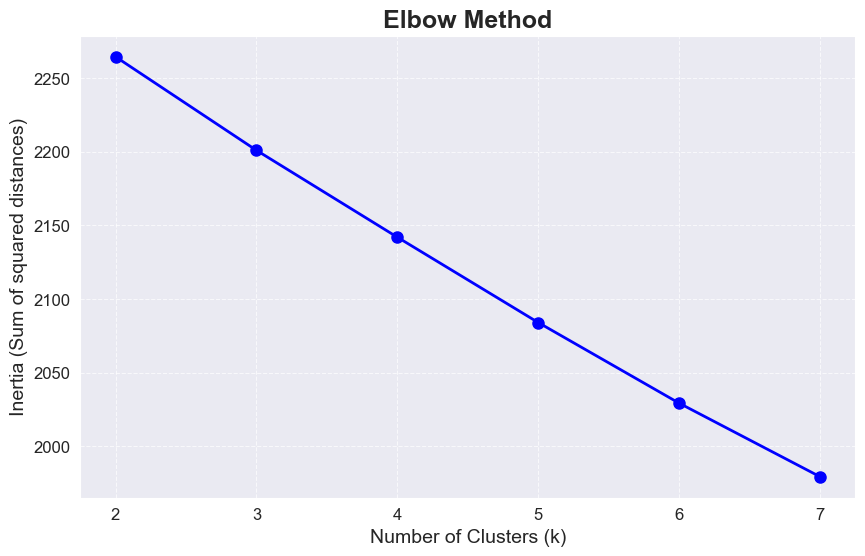

In [101]:
import numpy as np

k_range = range(2, 8)
inertias = []

for k in k_range:
    cluster_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = cluster_model.fit_predict(X_df)

    # Inertia calculation
    centroids = np.array([X_df[labels == i].mean(axis=0) for i in range(k)])
    inertia = sum(
        np.sum(np.linalg.norm(X_df[labels == i] - centroids[i], axis=1)**2)
        for i in range(k)
    )
    inertias.append(inertia)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.title('Elbow Method', fontsize=18, fontweight='bold')
plt.xlabel('Number of Clusters (k)', fontsize=14)
plt.ylabel('Inertia (Sum of squared distances)', fontsize=14)
plt.xticks(k_range, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Guardar o mostrar
plt.savefig('elbow_chart.png')

*Segmentation analysis*
